In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = pd.read_csv("housing_price_dataset.csv")
df.drop_duplicates(inplace=True)

cat_col = ['Neighborhood']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
encoded_feat = encoder.fit_transform(df[cat_col])
encoded_df = pd.DataFrame(encoded_feat, columns=encoder.get_feature_names_out(cat_col), index=df.index)

df = pd.concat([df.drop(columns=cat_col), encoded_df], axis=1)

X = df.drop(columns='Price')
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

params = {'alpha': [0.1, 1, 10, 50, 100]}

ridge_cv = GridSearchCV(Ridge(), params, cv=5)
ridge_cv.fit(X_train_scaled, y_train)
best_ridge = ridge_cv.best_estimator_

lasso_cv = GridSearchCV(Lasso(), params, cv=5)
lasso_cv.fit(X_train_scaled, y_train)
best_lasso = lasso_cv.best_estimator_

def evaluate(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    print(f"--- {name} ---")
    print(f"MAE: {mae:.2f}")
    print(f"R2 Score: {r2:.4f}\n")

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Best Ridge (Alpha: {})".format(ridge_cv.best_params_['alpha']), y_test, best_ridge.predict(X_test_scaled))
evaluate("Best Lasso (Alpha: {})".format(lasso_cv.best_params_['alpha']), y_test, best_lasso.predict(X_test_scaled))

plt.figure(figsize=(10, 5))
sns.residplot(x=lr_pred, y=y_test, lowess=True, color="g")
plt.title('Residuals: Predicted vs Actual')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.show()

In [9]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [11]:
df = pd.read_csv("housing_price_dataset.csv")

In [13]:
df.shape

(50000, 6)

In [15]:
df.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


In [17]:
df.drop_duplicates(inplace=True)

In [19]:
df.shape

(50000, 6)

In [21]:
df.isnull().sum()

SquareFeet      0
Bedrooms        0
Bathrooms       0
Neighborhood    0
YearBuilt       0
Price           0
dtype: int64

In [23]:
df.describe()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,2003.000000,279373.630052
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
sns.set_style('darkgrid')

<Axes: ylabel='SquareFeet'>

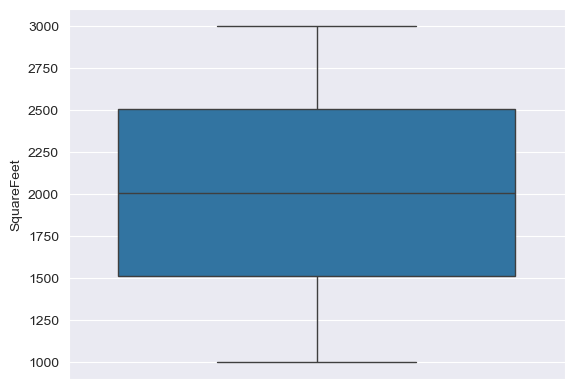

In [27]:
sns.boxplot(df, y = 'SquareFeet')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB


In [29]:
cat_col = df.select_dtypes('object').columns.tolist()

In [32]:
cat_col

['Neighborhood']

In [37]:
from sklearn.preprocessing import OneHotEncoder

In [39]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [41]:
encoder.fit(df[cat_col])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [43]:
encoded_cols = encoder.get_feature_names_out(cat_col)

In [45]:
encoded_cols

array(['Neighborhood_Rural', 'Neighborhood_Suburb', 'Neighborhood_Urban'],
      dtype=object)

In [47]:
df[encoded_cols] = encoder.transform(df[cat_col])

In [49]:
df

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban
0,2126,4,1,Rural,1969,215355.283618,1.0,0.0,0.0
1,2459,3,2,Rural,1980,195014.221626,1.0,0.0,0.0
2,1860,2,1,Suburb,1970,306891.012076,0.0,1.0,0.0
3,2294,2,1,Urban,1996,206786.787153,0.0,0.0,1.0
4,2130,5,2,Suburb,2001,272436.239065,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
49995,1282,5,3,Rural,1975,100080.865895,1.0,0.0,0.0
49996,2854,2,2,Suburb,1988,374507.656727,0.0,1.0,0.0
49997,2979,5,3,Suburb,1962,384110.555590,0.0,1.0,0.0
49998,2596,5,2,Rural,1984,380512.685957,1.0,0.0,0.0


In [51]:
df.drop(columns = cat_col, inplace= True)

In [53]:
df

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban
0,2126,4,1,1969,215355.283618,1.0,0.0,0.0
1,2459,3,2,1980,195014.221626,1.0,0.0,0.0
2,1860,2,1,1970,306891.012076,0.0,1.0,0.0
3,2294,2,1,1996,206786.787153,0.0,0.0,1.0
4,2130,5,2,2001,272436.239065,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
49995,1282,5,3,1975,100080.865895,1.0,0.0,0.0
49996,2854,2,2,1988,374507.656727,0.0,1.0,0.0
49997,2979,5,3,1962,384110.555590,0.0,1.0,0.0
49998,2596,5,2,1984,380512.685957,1.0,0.0,0.0


In [55]:
x = df.drop(columns = 'Price')
y = df['Price']

In [57]:
from sklearn.preprocessing import MinMaxScaler

In [59]:
scaler = MinMaxScaler()
scaler.fit(x)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [61]:
x[:] = scaler.transform(x)

In [63]:
x

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban
0,0.563282,0.666667,0.0,0.267606,1.0,0.0,0.0
1,0.729865,0.333333,0.5,0.422535,1.0,0.0,0.0
2,0.430215,0.000000,0.0,0.281690,0.0,1.0,0.0
3,0.647324,0.000000,0.0,0.647887,0.0,0.0,1.0
4,0.565283,1.000000,0.5,0.718310,0.0,1.0,0.0
...,...,...,...,...,...,...,...
49995,0.141071,1.000000,1.0,0.352113,1.0,0.0,0.0
49996,0.927464,0.000000,0.5,0.535211,0.0,1.0,0.0
49997,0.989995,1.000000,1.0,0.169014,0.0,1.0,0.0
49998,0.798399,1.000000,0.5,0.478873,1.0,0.0,0.0


In [65]:
from sklearn.model_selection import train_test_split

In [67]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [69]:
x_train.shape, x_test.shape , y_train.shape, y_test.shape

((40000, 7), (10000, 7), (40000,), (10000,))

In [71]:
from sklearn.linear_model import LinearRegression

In [73]:
model = LinearRegression()

In [75]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [77]:
y_pred = model.predict(x_test)

In [79]:
y_test[:5]

33553    170835.035713
9427     126913.469998
199      246611.883092
12447    244250.462969
39489    271127.650112
Name: Price, dtype: float64

In [81]:
y_pred[:5]

array([218329.49032129, 135025.03293153, 255260.82445864, 257831.41150107,
       277383.66705202])

In [132]:
from sklearn.metrics import mean_squared_error, r2_score

In [134]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 2436249371.3072467
R2 Score: 0.5755628630306235


In [136]:
from sklearn.metrics import mean_absolute_error

In [138]:
mean_absolute_error(y_test, y_pred)

39430.16533829792

In [87]:
from sklearn.linear_model import Lasso

In [89]:
lasso_model= Lasso(alpha = 50, max_iter= 100, tol=0.1)

In [91]:
lasso_model.fit(x_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",50
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",100
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.1
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [93]:
lasso_pred = lasso_model.predict(x_test)

In [95]:
mean_absolute_error(y_test, lasso_pred)

39430.003733121644

In [97]:
from sklearn.linear_model import Ridge

In [99]:
ridge_model = Ridge(alpha = 50, max_iter = 100, tol= 0.1)

In [101]:
ridge_model.fit(x_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",50
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",100
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.1
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [103]:
ridge_pred = ridge_model.predict(x_test)

In [105]:
mean_absolute_error(y_test, ridge_pred)

39433.47767719194